In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,classification_report, f1_score, roc_auc_score,precision_recall_curve

In [4]:
df = pd.read_csv(r"credit_risk_data1",index_col=[0])
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,past_default_status,cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


Separate features and target

In [5]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]


Data Preprocessing

In [6]:
nominal_cols = ["person_home_ownership", "loan_intent"]
ordinal_cols = ["loan_grade"]
binary_cols = ["past_default_status"]
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),

        ("nominal",
         OneHotEncoder(drop="first", handle_unknown="ignore"),
         nominal_cols),

        ("binary",
         OrdinalEncoder(categories=[["N", "Y"]]),
         binary_cols),

        ("ordinal",
         OrdinalEncoder(categories=[["A","B","C","D","E","F","G"]]),
         ordinal_cols)
    ]
)

Train-Test-Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


ML Algorithms available for binary classification:-
- Logistic regression , Support Vector Machines , Naive Bayes ,Decision Tree , Random Forest ,KNN ,AdaBoost, Gradient Boosting (XGBoost /LightGBM),CatBoost
- SVM is expensive and less scalable for large datasets
- Adaboost is base foundation for Gradient Boosting XGBoost , LightGBM and catboost


In [11]:
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]

cat_class_weights = [1.0, scale_pos_weight]

## Logistic Regression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])



# Decision Tree

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ))
])



# Random Forest

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])



# XGBoost

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])


# CatBoost

from catboost import CatBoostClassifier

cat_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostClassifier(
        random_state=42,
        verbose=0,
        class_weights=cat_class_weights
    ))
])

from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [12]:
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "CatBoost": cat_pipeline,
    "LightGBM": lgbm_pipeline
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(results_df)

[LightGBM] [Info] Number of positive: 5221, number of negative: 18095
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 954
[LightGBM] [Info] Number of data points in the train set: 23316, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
4             CatBoost  0.921395   0.844933  0.794945  0.819177  0.944851
5             LightGBM  0.916249   0.821724  0.799540  0.810480  0.944428
3              XGBoost  0.915348   0.821365  0.794945  0.807939  0.941628
2        Random Forest  0.931558   0.971161  0.715681  0.824074  0.929393
0  Logistic Regression  0.790557   0.521756  0.778288  0.624712  0.863260
1 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Check model performance

In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [17]:
pipelines = {
    "CatBoost": cat_pipeline,
    "LightGBM": lgbm_pipeline,
    "XGBoost": xgb_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "Logistic Regression": lr_pipeline
}

for name, model in pipelines.items():
    model.fit(X_train, y_train)
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"{name} | Train AUC: {train_auc:.3f} | Test AUC: {test_auc:.3f}")

CatBoost | Train AUC: 0.983 | Test AUC: 0.945
[LightGBM] [Info] Number of positive: 5221, number of negative: 18095
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015724 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 954
[LightGBM] [Info] Number of data points in the train set: 23316, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM | Train AUC: 0.979 | Test AUC: 0.944
XGBoost | Train AUC: 0.995 | Test AUC: 0.942
Decision Tree | Train AUC: 1.000 | Test AUC: 0.845
Random Forest | Train AUC: 1.000 | Test AUC: 0.929
Logistic Regression | Train AUC: 0.866 | Test AUC: 0.863


- Random Forest has high accuracy but low recall
- LightBGM and XGBoost has strong performance but lower F1 score and ROC-AUC than CatBoost
- Logistic regression has high recall but poor precision - too many false positives
- Decision tree is giving good results but weaker than ensemble methods
- So, the best model for our problem is **CatBoost**

In [34]:
cat_features = ["loan_intent", "loan_grade", "past_default_status","person_home_ownership"]

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    eval_metric='AUC',
    verbose=0,
    random_state=42,
    early_stopping_rounds=50
)
cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    cat_features=["loan_intent", "loan_grade", "past_default_status","person_home_ownership"]  # only non-encoded categorical
)

CatBoostClassifier(depth=6, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, learning_rate=0.1, random_state=42, verbose=0)

In [35]:
y_probs = cat_model.predict_proba(X_test)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_thresh = thresholds[f1_scores.argmax()]
print(f"Best threshold by F1: {best_thresh:.3f}")

Best threshold by F1: 0.481


In [36]:
y_pred = (y_probs >= best_thresh).astype(int)
print("Classification Report at Best Threshold:")
print(classification_report(y_test, y_pred))

Classification Report at Best Threshold:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      6032
           1       0.98      0.74      0.84      1741

    accuracy                           0.94      7773
   macro avg       0.96      0.87      0.90      7773
weighted avg       0.94      0.94      0.93      7773



Best threshold by F1 score: 0.630


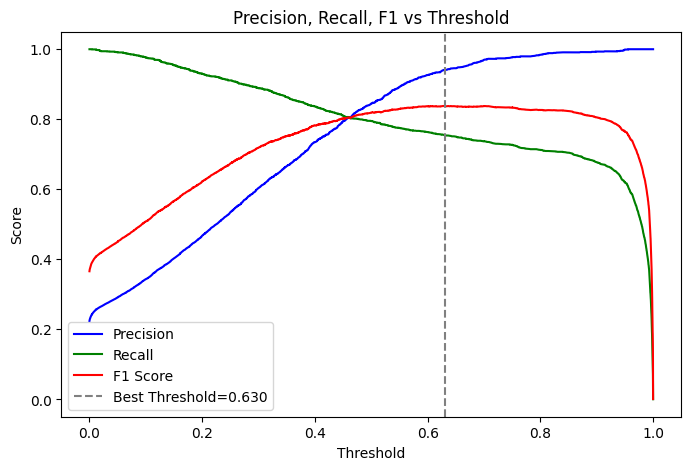

In [37]:
# Get predicted probabilities for the positive class
y_probs = cat_pipeline.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall)

# Find threshold with maximum F1
best_thresh = thresholds[f1_scores.argmax()]
print(f"Best threshold by F1 score: {best_thresh:.3f}")

# Plot Precision, Recall, and F1 vs Threshold
plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='red')
plt.axvline(x=best_thresh, color='gray', linestyle='--', label=f'Best Threshold={best_thresh:.3f}')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold")
plt.legend()
plt.show()

# Optional: predictions using best threshold
y_pred = (y_probs >= best_thresh).astype(int)

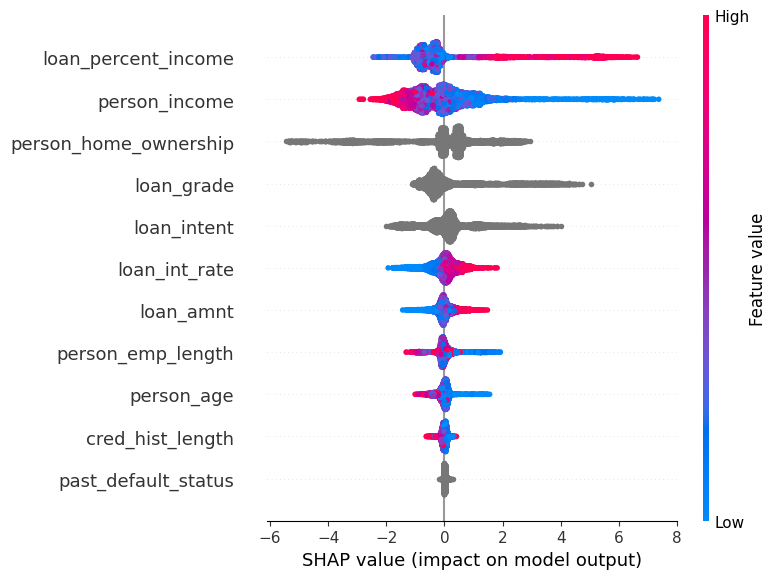

In [38]:
import shap
explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)



Predict on sample datapoint

In [41]:
y_test.iloc[0]

np.int64(0)

In [39]:
sample_row = X_test.iloc[[0]]
prob = cat_model.predict_proba(sample_row)[:,1][0]
print(f"Predicted probability of default: {prob:.3f}")
pred_class_default = cat_model.predict(sample_row)[0]
print(f"Predicted class (threshold=0.5): {pred_class_default}")
best_threshold = 0.35  # example threshold
pred_class_tuned = 1 if prob >= best_threshold else 0
print(f"Predicted class (threshold={best_threshold}): {pred_class_tuned}")

Predicted probability of default: 0.026
Predicted class (threshold=0.5): 0
Predicted class (threshold=0.35): 0
